In [1]:
import sys
from pathlib import Path
repo_root = Path().resolve().parent  
sys.path.append(str(repo_root))

In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.cluster import KMeans
import joblib
import plotly.graph_objects as go
import plotly.express as px 
import plotly.io as pio
import plotly.subplots as sp
from sklearn.pipeline import Pipeline 
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.Tenth_Best_Time_Estimator import TenthBestTimeEstimator
from src.data.Segment_Slicer import SegmentSlicer 
segment_slicer = SegmentSlicer()
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
df= pd.read_parquet(repo_root / 'data' / 'processed' / 'reunion_segments_cleaned.parquet')

In [4]:
print(f"📊 Dataset: {len(df)} segments")
print(f"   Running: {(df['activity_type']=='Run').sum()}")
print(f"   Cycling: {(df['activity_type']=='Ride').sum()}")

📊 Dataset: 2848 segments
   Running: 1470
   Cycling: 1378


In [5]:
# Création de la figure avec deux sous-graphiques
fig = sp.make_subplots(rows=2, cols=1,
                    subplot_titles=("Distribution of Effort Counts", "Best Time vs Effort Count"),
                    vertical_spacing=0.15)

# 1. Histogramme (échelle log)
histogram = go.Histogram(
    x=df['total_effort_count'],
    nbinsx=50,
    marker=dict(color='blue', line=dict(color='black', width=1)),
    name='Effort Count'
)
fig.add_trace(histogram, row=1, col=1)

# Ligne de seuil (500)
fig.add_vline(x=500, line=dict(color='red', dash='dash'), row=1, col=1, annotation_text="Threshold (500)", annotation_position="top right")

# Configuration de l'échelle log pour l'axe y
fig.update_yaxes(type="log", row=1, col=1)
fig.update_xaxes(title_text="Total Efforts", row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=1)

# 2. Scatter plot (échelle log pour x, colorbar pour la distance)
scatter = go.Scatter(
    x=df['total_effort_count'],
    y=df['best_time'],
    mode='markers',
    marker=dict(
        size=8,
        color=df['distance']/1000,
        colorscale='Viridis',
        opacity=0.6,
        showscale=True,
        colorbar=dict(title='Distance (km)')
    ),
    name='Best Time'
)
fig.add_trace(scatter, row=2, col=1)

# Configuration des axes pour le scatter plot
fig.update_xaxes(type="log", title_text="Total Efforts", row=2, col=1)
fig.update_yaxes(title_text="Best Time (s)", row=2, col=1)

# Mise en page finale
fig.update_layout(
    height=800,
    width=800,
    showlegend=False,
    title_text="Effort Count Analysis"
)

# Affichage
fig.show()

In [6]:
Train, Test = train_test_split(df, test_size=0.2, random_state=42)
Train, Val = train_test_split(Train, test_size=0.1, random_state=42)
print(f"Train: {len(Train)}, Val: {len(Val)}, Test: {len(Test)}")

Train: 2050, Val: 228, Test: 570


In [7]:
# Séparer Ride et Run
Train_ride = Train[Train['activity_type'] == 'Ride'].copy()
Train_run = Train[Train['activity_type'] == 'Run'].copy()

Val_ride = Val[Val['activity_type'] == 'Ride'].copy()
Val_run = Val[Val['activity_type'] == 'Run'].copy()

Test_ride = Test[Test['activity_type'] == 'Ride'].copy()
Test_run = Test[Test['activity_type'] == 'Run'].copy()

In [8]:
print(f"Train Ride: {len(Train_ride)}, Run: {len(Train_run)}")
print(f"Val Ride: {len(Val_ride)}, Run: {len(Val_run)}")
print(f"Test Ride: {len(Test_ride)}, Run: {len(Test_run)}")

Train Ride: 983, Run: 1067
Val Ride: 110, Run: 118
Test Ride: 285, Run: 285


In [9]:
print("columns:", Train_ride.columns.tolist())

columns: ['segment_id', 'name', 'activity_type', 'distance', 'elevation_gain', 'elevation_low', 'elevation_high', 'best_time', 'average_top_10_time', 'tenth_best_time', 'total_effort_count', 'total_athlete_count', 'altitude_profile', 'distance_profile', 'coordinates']


### Physic-based model

In [10]:
def effort_correction_model(total_effort_count, best_time, asymptote_factor=0.95):

    high_effort_mask = total_effort_count > 1000
    
    if high_effort_mask.sum() > 50:
        
        high_effort_data = total_effort_count[high_effort_mask]

        target_high_effort_ratio = 0.92  # évite log(0)
        denominator = 1 - target_high_effort_ratio / asymptote_factor

        if denominator <= 0:
            denominator = 1e-6

        k_param = -np.log(denominator) / np.median(high_effort_data)

        def saturation_curve(effort, k):
            return asymptote_factor * (1 - np.exp(-k * effort))

        correction_factor = saturation_curve(total_effort_count, k_param)
        theoretical_best = best_time * correction_factor

        return theoretical_best, correction_factor
    
    else:
        return best_time * 0.95, np.ones_like(best_time) * 0.95


In [11]:
Train_ride = Train_ride.copy()

total_effort = Train_ride["total_effort_count"].values
best_time    = Train_ride["best_time"].values

theoretical_best, correction_factor = effort_correction_model(
    total_effort_count = total_effort,
    best_time = best_time,
    asymptote_factor = 0.95
)

Train_ride.loc[:, "theoretical_best_time"] = theoretical_best
Train_ride.loc[:, "effort_correction_factor"] = correction_factor


### ML model

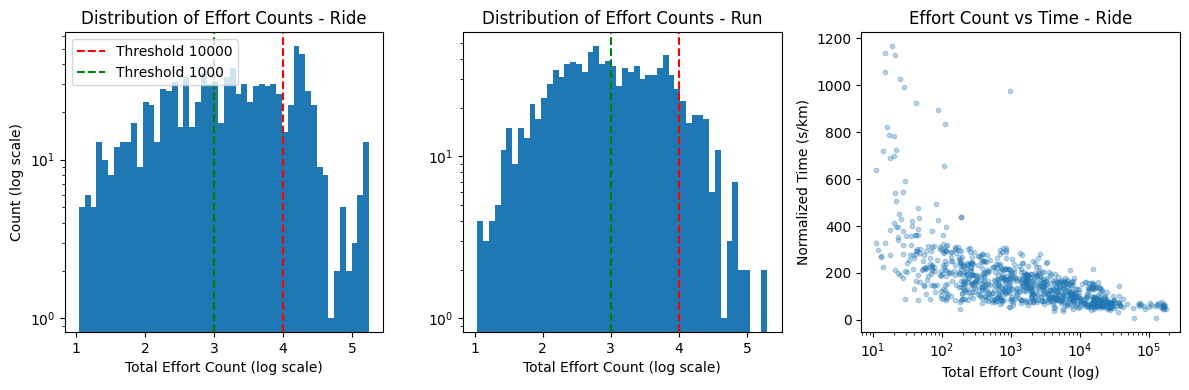

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(np.log10(Train_ride['total_effort_count']), bins=50, log=True)
plt.axvline(np.log10(10000), color='r', linestyle='--', label='Threshold 10000')
plt.axvline(np.log10(1000), color='g', linestyle='--', label='Threshold 1000')
plt.xlabel('Total Effort Count (log scale)')
plt.ylabel('Count (log scale)')
plt.title('Distribution of Effort Counts - Ride')
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(np.log10(Train_run['total_effort_count']), bins=50, log=True)
plt.axvline(np.log10(10000), color='r', linestyle='--')
plt.axvline(np.log10(1000), color='g', linestyle='--')
plt.xlabel('Total Effort Count (log scale)')
plt.title('Distribution of Effort Counts - Run')

plt.subplot(1, 3, 3)
# Relation entre effort_count et best_time (normalisé par distance)
Train_ride['norm_time'] = Train_ride['best_time'] / (Train_ride['distance'] / 1000)
plt.scatter(Train_ride['total_effort_count'], Train_ride['norm_time'], 
            alpha=0.3, s=10)
plt.xscale('log')
plt.xlabel('Total Effort Count (log)')
plt.ylabel('Normalized Time (s/km)')
plt.title('Effort Count vs Time - Ride')

plt.tight_layout()
plt.show()

In [13]:
effort_threshold_ride = 10000
effort_threshold_run = 10000

In [14]:
Train_ride_high = Train_ride[Train_ride['total_effort_count'] >= effort_threshold_ride].copy()
Train_run_high = Train_run[Train_run['total_effort_count'] >= effort_threshold_run].copy()
print(f"High-effort segments - Ride: {len(Train_ride_high)}, Run: {len(Train_run_high)}")

High-effort segments - Ride: 228, Run: 131


In [15]:
def extract_features_from_segment(segment_row, segment_id, max_sections=50):
    """
    Extrait les features d'un segment en utilisant SegmentSlicer
    """
    # Charger le profil du segment (tu dois avoir ça quelque part)
    altitude_profile, distance_profile, coordinates = segment_row['altitude_profile'], segment_row['distance_profile'], segment_row['coordinates']
    
    
    sections = segment_slicer.cut_segment(altitude_profile, distance_profile, coordinates)  
    
    # ========== Section-level features ==========
    section_features = []
    for s in sections:
        section_features.append([
            s['distance'] / 1000,  # km
            s['elevation_gain'],
            s['elevation_loss'],
            s['grade'],
            s['max_grade'],
            s['min_grade'],
            s['grade_variance'],
            1 if s['type'] in ['climb', 'uphill'] else 0,  # is_climb
            1 if s['type'] in ['descent', 'downhill'] else 0,  # is_descent
        ])
    
    section_features = np.array(section_features)
    
    # Padding
    n_sections, n_features = section_features.shape
    if n_sections > max_sections:
        section_features = section_features[:max_sections]
    else:
        padded = np.zeros((max_sections, n_features))
        padded[:n_sections] = section_features
        section_features = padded
    
    # ========== Global features ==========
    total_distance = sum(s['distance'] for s in sections) / 1000  # km
    total_elevation_gain = sum(s['elevation_gain'] for s in sections)
    total_elevation_loss = sum(s['elevation_loss'] for s in sections)
    
    # Weighted grade (fatigue effect)
    weighted_grade = 0
    for i, s in enumerate(sections):
        weight = 1 + (i / len(sections)) * 0.5  # 1.0 to 1.5x
        weighted_grade += s['grade'] * weight * s['distance']
    weighted_grade /= sum(s['distance'] for s in sections)
    
    # Climb distribution (early vs late)
    total_dist = sum(s['distance'] for s in sections)
    early_climb = sum(s['elevation_gain'] for s in sections 
                      if s['start_distance'] < total_dist * 0.3)
    late_climb = sum(s['elevation_gain'] for s in sections 
                     if s['start_distance'] > total_dist * 0.7)
    
    global_features = np.array([
        total_distance,
        total_elevation_gain,
        total_elevation_loss,
        np.mean([s['grade'] for s in sections]),
        max(s['max_grade'] for s in sections),
        min(s['min_grade'] for s in sections),
        weighted_grade,
        early_climb / (total_elevation_gain + 1e-6),
        late_climb / (total_elevation_gain + 1e-6),
        len(sections),
        np.mean([s['grade_variance'] for s in sections]),
    ])
    
    # ========== Sampling features (pour Option 2) ==========
    sampling_features = np.array([
        np.log1p(segment_row['total_effort_count']),
        np.log1p(segment_row['total_athlete_count']),
        segment_row['best_time'],
    ])
    
    return section_features, global_features, sampling_features

In [16]:
first_segment = Train_ride_high.iloc[0]
print(segment_slicer.cut_segment(first_segment['altitude_profile'], first_segment['distance_profile'], first_segment['coordinates'] ))

[{'type': 'climb', 'category': 'Cat 4', 'start_distance': np.float64(0.0), 'end_distance': np.float64(1539.0999999999985), 'distance': np.float64(1539.0999999999985), 'start_altitude': np.float64(975.4), 'end_altitude': np.float64(1093.8), 'elevation_gain': np.float64(118.0), 'elevation_loss': 0, 'elevation_change': np.float64(118.0), 'grade': np.float64(7.666818270417784), 'max_grade': np.float64(12.322508344696036), 'min_grade': np.float64(-0.3919519127801832), 'grade_variance': np.float64(5.224965069982549), 'start_idx': 0, 'end_idx': 348}, {'type': 'flat', 'category': 'Uncategorized', 'start_distance': np.float64(1539.0999999999985), 'end_distance': np.float64(1606.0), 'distance': np.float64(66.90000000000146), 'start_altitude': np.float64(1093.8), 'end_altitude': np.float64(1092.4), 'elevation_gain': 0, 'elevation_loss': np.float64(1.3999999999998636), 'elevation_change': np.float64(-1.3999999999998636), 'grade': np.float64(-0.8926018419151269), 'max_grade': np.float64(1.958731951

In [17]:
Features = extract_features_from_segment(Train_ride_high, segment_id=Train_ride_high.index[0])
print("Section Features for the first segment:", Features[0][0])
print("Global Features for the first segment:", Features[1][0])
print("Sampling Features for the first segment:", Features[2][0])

ValueError: operands could not be broadcast together with shapes (272,) (1431,) 

In [18]:
def prepare_dataset(df, max_sections=50):
    """Prépare X et y pour l'entraînement"""
    X_sections = []
    X_global = []
    X_sampling = []
    y = []
    valid_indices = []
    
    for idx, row in df.iterrows():
        seg_id = row['segment_id']
        
        try:
            sec_feat, glob_feat, samp_feat = extract_features_from_segment(
                row, seg_id, max_sections
            )
            
            if sec_feat is not None:
                X_sections.append(sec_feat)
                X_global.append(glob_feat)
                X_sampling.append(samp_feat)
                y.append(row['best_time'])
                valid_indices.append(idx)
        except Exception as e:
            print(f"Error processing segment {seg_id}: {e}")
            continue
    
    return (np.array(X_sections), np.array(X_global), np.array(X_sampling), 
            np.array(y), valid_indices)

In [19]:
# Pour Ride (high-effort only pour entraînement)
print("Preparing Ride dataset...")
X_sec_ride, X_glob_ride, X_samp_ride, y_ride, _ = prepare_dataset(Train_ride_high)

# Pour Run
print("Preparing Run dataset...")
X_sec_run, X_glob_run, X_samp_run, y_run, _ = prepare_dataset(Train_run_high)

Preparing Ride dataset...
Preparing Run dataset...


In [22]:
def build_theoretical_time_model(n_section_features, n_global_features, 
                                  max_sections=50):
    """
    Modèle simple: prédit le temps basé sur terrain uniquement
    N'utilise PAS effort_count en input (pour éviter data leakage)
    """
    
    # Section sequence
    section_input = layers.Input(shape=(max_sections, n_section_features))
    mask = layers.Masking(mask_value=0.0)(section_input)
    
    # Bidirectional LSTM pour capturer ordre et fatigue
    lstm = layers.Bidirectional(
        layers.LSTM(32, return_sequences=False, dropout=0.3, recurrent_dropout=0.2)
    )(mask)
    
    # Global features
    global_input = layers.Input(shape=(n_global_features,))
    global_dense = layers.Dense(32, activation='relu')(global_input)
    
    # Combine
    combined = layers.Concatenate()([lstm, global_dense])
    
    # Dense layers
    dense1 = layers.Dense(64, activation='relu', 
                         kernel_regularizer=keras.regularizers.l2(0.01))(combined)
    dense1 = layers.Dropout(0.4)(dense1)
    
    dense2 = layers.Dense(32, activation='relu',
                         kernel_regularizer=keras.regularizers.l2(0.01))(dense1)
    dense2 = layers.Dropout(0.3)(dense2)
    
    # Output
    output = layers.Dense(1)(dense2)
    
    model = keras.Model(inputs=[section_input, global_input], outputs=output)
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae', 'mape']
    )
    
    return model

# Build models
model_ride = build_theoretical_time_model(
    n_section_features=X_sec_ride.shape[2],
    n_global_features=X_glob_ride.shape[1]
)

model_run = build_theoretical_time_model(
    n_section_features=X_sec_run.shape[2],
    n_global_features=X_glob_run.shape[1]
)

In [23]:
X_sec_val_ride, X_glob_val_ride, _, y_val_ride, _ = prepare_dataset(Val_ride)

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        patience=20, 
        restore_best_weights=True,
        monitor='val_loss'
    ),
    keras.callbacks.ReduceLROnPlateau(
        patience=10, 
        factor=0.5,
        monitor='val_loss'
    ),
    keras.callbacks.ModelCheckpoint(
        'best_model_ride.h5',
        save_best_only=True,
        monitor='val_loss'
    )
]

In [24]:
history_ride = model_ride.fit(
    [X_sec_ride, X_glob_ride], y_ride,
    validation_data=([X_sec_val_ride, X_glob_val_ride], y_val_ride),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 136902.4326 - mae: 221.6952 - mape: 96.4176

8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 448ms/step - loss: 120166.5938 - mae: 210.5142 - mape: 95.5575 - val_loss: 805066.6250 - val_mae: 500.0384 - val_mape: 99.5133 - learning_rate: 0.0010
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 103750.8389 - mae: 213.2054 - mape: 93.8453

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - loss: 113115.6562 - mae: 202.9513 - mape: 94.9113 - val_loss: 769798.5625 - val_mae: 485.8058 - val_mape: 103.5365 - learning_rate: 0.0010
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 121494.8252 - mae: 209.5163 - mape: 90.9558

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - loss: 109658.0078 - mae: 197.1422 - mape: 91.3774 - val_loss: 728296.4375 - val_mae: 468.5630 - val_mape: 106.8401 - learning_rate: 0.0010
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 80910.5010 - mae: 180.8756 - mape: 86.3614

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - loss: 100893.3672 - mae: 189.3648 - mape: 83.5304 - val_loss: 684826.0625 - val_mae: 449.5039 - val_mape: 111.7795 - learning_rate: 0.0010
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 113371.9697 - mae: 193.1425 - mape: 82.6802

...

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 19418.6934 - mae: 87.0704 - mape: 82.3690 - val_loss: 201968.3594 - val_mae: 201.3810 - val_mape: 71.1918 - learning_rate: 0.0010
Epoch 30/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - loss: 23983.2246 - mae: 94.5122 - mape: 83.1171 - val_loss: 202928.4688 - val_mae: 200.9690 - val_mape: 68.7687 - learning_rate: 0.0010
Epoch 31/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - loss: 24952.0605 - mae: 88.8849 - mape: 74.4126 - val_loss: 219749.5625 - val_mae: 210.0269 - val_mape: 63.0315 - learning_rate: 0.0010
Epoch 32/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - loss: 19746.2988 - mae: 84.5868 - mape: 67.4722 - val_loss: 252008.9062 - val_mae: 228.9311 - val_mape: 57.8655 - learning_rate: 0.0010
Epoch 33/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 212ms/step - loss: 23800.0078 - mae: 89.1902 - mape: 60.8796 - val_loss: 266446.0000 - val_mae: 236.6055 - val_mape: 56.4235 - learning_rate: 0.0010
Epoch 34/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - loss: 2312

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - loss: 17720.3359 - mae: 82.2402 - mape: 73.2904 - val_loss: 192519.7812 - val_mae: 190.7785 - val_mape: 61.4605 - learning_rate: 0.0010
Epoch 36/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 21442.5314 - mae: 88.1831 - mape: 90.5970

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - loss: 22279.5176 - mae: 90.0247 - mape: 86.7443 - val_loss: 175155.2188 - val_mae: 182.5891 - val_mape: 62.7379 - learning_rate: 0.0010
Epoch 37/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 26693.2480 - mae: 93.2116 - mape: 82.3942 - val_loss: 177576.4062 - val_mae: 183.0099 - val_mape: 57.7700 - learning_rate: 0.0010
Epoch 38/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - loss: 18026.3320 - mae: 81.8587 - mape: 74.0314 - val_loss: 185238.2500 - val_mae: 188.0804 - val_mape: 54.3323 - learning_rate: 0.0010
Epoch 39/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - loss: 18124.7285 - mae: 81.1162 - mape: 70.1054 - val_loss: 179863.2969 - val_mae: 184.8686 - val_mape: 53.0103 - learning_rate: 0.0010
Epoch 40/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - loss: 15210.4834 - mae: 72.6006 - mape: 60.9311 - val_loss: 184533.8125 - val_mae: 188.9683 - val_mape: 52.2647 - learning_rate: 0.0010
Epoch 41/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step - loss: 1693

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 17284.2539 - mae: 76.4496 - mape: 68.9156 - val_loss: 163199.8594 - val_mae: 182.1484 - val_mape: 52.5126 - learning_rate: 5.0000e-04
Epoch 52/100
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 14798.5112 - mae: 67.0489 - mape: 57.7955

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 16548.7480 - mae: 74.6161 - mape: 66.3859 - val_loss: 151263.8594 - val_mae: 172.5570 - val_mape: 52.5752 - learning_rate: 5.0000e-04
Epoch 53/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 10663.9971 - mae: 66.5160 - mape: 60.3024 - val_loss: 154347.8750 - val_mae: 174.4922 - val_mape: 50.8884 - learning_rate: 5.0000e-04
Epoch 54/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 16789.2734 - mae: 74.3116 - mape: 59.9938 - val_loss: 176864.2500 - val_mae: 192.4815 - val_mape: 49.2934 - learning_rate: 5.0000e-04
Epoch 55/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 16741.0312 - mae: 78.3878 - mape: 62.6608 - val_loss: 187231.1875 - val_mae: 200.1668 - val_mape: 48.5588 - learning_rate: 5.0000e-04
Epoch 56/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 15217.8408 - mae: 75.6558 - mape: 65.4426 - val_loss: 190912.4531 - val_mae: 202.9892 - val_mape: 48.4081 - learning_rate: 5.0000e-04
Epoch 57/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/s

In [25]:
def evaluate_model(model, X_sec, X_glob, y_true, effort_counts, name=""):
    """
    Évalue le modèle en stratifiant par effort_count
    """
    y_pred = model.predict([X_sec, X_glob], verbose=0).flatten()
    
    # Métriques globales
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    
    print(f"\n{name} - Global Metrics:")
    print(f"  MAE: {mae:.2f}s")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  RMSE: {rmse:.2f}s")
    
    # Métriques par strate d'effort
    print(f"\n{name} - Metrics by Effort Count:")
    
    strata = [
        (0, 100, "Very Low"),
        (100, 500, "Low"),
        (500, 1000, "Medium"),
        (1000, 5000, "High"),
        (5000, np.inf, "Very High")
    ]
    
    for low, high, label in strata:
        mask = (effort_counts >= low) & (effort_counts < high)
        if mask.sum() > 0:
            strata_mae = np.mean(np.abs(y_true[mask] - y_pred[mask]))
            strata_mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
            print(f"  {label:12} (n={mask.sum():4}): MAE={strata_mae:6.2f}s, MAPE={strata_mape:5.2f}%")
    
    return y_pred

In [26]:
y_pred_val_ride = evaluate_model(
    model_ride, 
    X_sec_val_ride, X_glob_val_ride, y_val_ride,
    Val_ride['total_effort_count'].values,
    "Validation Ride"
)


Validation Ride - Global Metrics:
  MAE: 172.56s
  MAPE: 52.58%
  RMSE: 388.92s

Validation Ride - Metrics by Effort Count:
  Very Low     (n=  13): MAE=430.92s, MAPE=83.78%
  Low          (n=  16): MAE=185.51s, MAPE=34.91%
  Medium       (n=  14): MAE=201.19s, MAPE=36.40%
  High         (n=  29): MAE=187.00s, MAPE=30.52%
  Very High    (n=  38): MAE= 57.14s, MAPE=72.13%
